In [7]:
from ultralytics import YOLO

# 1. Khởi tạo mô hình (Dùng bản YOLOv8 nano - nhỏ và nhẹ nhất để máy cá nhân chạy nổi)
print("Đang tải bộ khung YOLOv8...")
model = YOLO('yolov8n.pt') 

# 2. Bắt đầu quá trình "nấu ăn" (Huấn luyện)
# Nhớ đổi đường dẫn 'data.yaml' thành đường dẫn thực tế trên máy bạn
print("Bắt đầu cho AI học nhìn biển số...")
results = model.train(
    data='D:/CCNLTHD/archive/archive/dataset.yaml', # ĐƯỜNG DẪN NÀY RẤT QUAN TRỌNG
    epochs=50,       # Cho AI học lặp đi lặp lại 20 vòng (chạy demo thì để 10-20 vòng cũng được)
    imgsz=640,       # Cố định kích thước ảnh 640x640
    batch=8,         # Mỗi lần nhét 8 ảnh vào
    device='cpu',    # Nếu máy bạn không có card rời NVIDIA thì để 'cpu'
    project='LPR_Project', # Tên thư mục lưu kết quả
    name='train_bien_so'   # Tên phiên chạy
)

print("🎉 Nấu ăn xong! Hãy kiểm tra thư mục LPR_Project/train_bien_so/weights/best.pt")

Đang tải bộ khung YOLOv8...
Bắt đầu cho AI học nhìn biển số...
Ultralytics 8.4.24  Python-3.13.9 torch-2.10.0+cu130 CPU (11th Gen Intel Core i5-11400H @ 2.70GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:/CCNLTHD/archive/archive/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_bien_so6, nbs=64, nms

⏳ Đang nạp mô hình...
🔍 AI đang tìm biển số...

image 1/1 D:\CCNLTHD\Bin_s_xe_ng_thp.jpg: 448x640 1 license_plate, 173.3ms
Speed: 14.7ms preprocess, 173.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


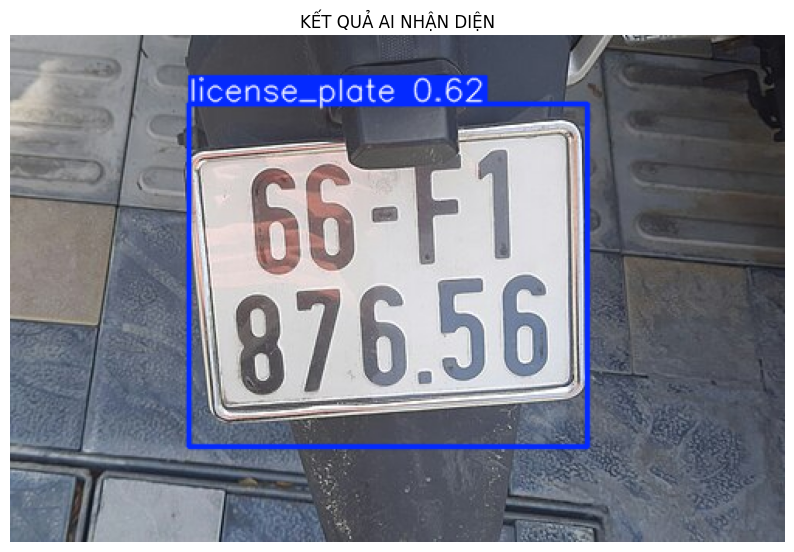


--- TỌA ĐỘ TÌM ĐƯỢC ---
Tọa độ [x1, y1, x2, y2]: [115.08937072753906, 44.591331481933594, 372.76507568359375, 265.2490234375]
Độ tự tin (AI chắc chắn bao nhiêu %): 62.00%


In [3]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Nạp "chất xám" (Mô hình bạn vừa train xong)
# Nếu chạy trên máy tính: Thay bằng đường dẫn tới file best.pt bạn tải về (VD: 'models/best.pt')
# Nếu chạy trên Colab: Đường dẫn thường là '/content/drive/MyDrive/LPR_Project/train_bien_so_lan_1/weights/best.pt'
model_path = 'D:/CCNLTHD/runs/detect/LPR_Project/train_bien_so6/weights/best.pt'
print("⏳ Đang nạp mô hình...")
model = YOLO(model_path)

# 2. Chọn 1 tấm ảnh Toàn cảnh chiếc xe để test
# Lấy 1 tấm ảnh trong thư mục val hoặc tải đại 1 ảnh xe trên mạng về test cho khách quan
image_path = 'D:/CCNLTHD/Biển_số_xe_đồng_tháp.jpg'

# 3. Cho AI "nhìn" và phán đoán
print("🔍 AI đang tìm biển số...")
results = model(image_path)

# 4. Vẽ kết quả lên màn hình
for r in results:
    # Hàm plot() của YOLO tự động vẽ cái khung chữ nhật và ghi độ tự tin (Confidence Score) lên ảnh
    im_array = r.plot()  
    
    # Chuyển hệ màu để hiển thị đúng trên Notebook
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

    # Hiển thị ảnh
    plt.figure(figsize=(10, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title("KẾT QUẢ AI NHẬN DIỆN")
    plt.show()
    
    # In ra Terminal tọa độ cụ thể để xem cho rõ
    print("\n--- TỌA ĐỘ TÌM ĐƯỢC ---")
    if len(r.boxes) == 0:
        print("Căng! AI không tìm thấy cái biển số nào trong hình này.")
    else:
        for box in r.boxes:
            print(f"Tọa độ [x1, y1, x2, y2]: {box.xyxy[0].tolist()}")
            print(f"Độ tự tin (AI chắc chắn bao nhiêu %): {box.conf[0].item() * 100:.2f}%")

⏳ Đang khởi động hệ thống AI...


[2026-03-26 21:56:38,173] [ WARNING] easyocr.py:71 - Using CPU. Note: This module is much faster with a GPU.


✅ Hệ thống đã sẵn sàng!


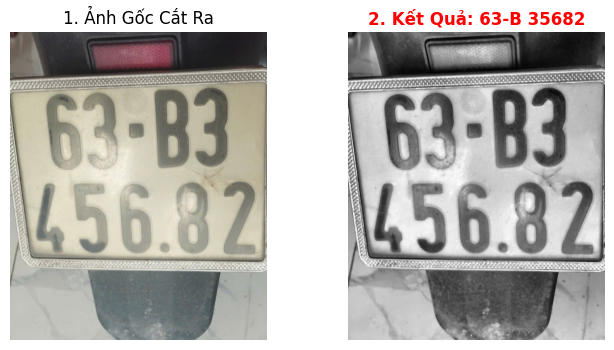


🚗 BIỂN SỐ LÀ  : 63-B 35682
🎯 ĐỘ TỰ TIN   : 76.43%



In [37]:
import cv2
import easyocr
import re
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

class LicensePlateReader:
    def __init__(self, yolo_weights_path):
        print("⏳ Đang khởi động hệ thống AI...")
        self.yolo = YOLO(yolo_weights_path)
        # Bật allowlist ngay từ đầu để ép AI chỉ đọc số và chữ cái tiếng Anh
        self.ocr = easyocr.Reader(['en'], gpu=False)
        print("✅ Hệ thống đã sẵn sàng!")

    def enhance_image(self, cropped_img):
        """Lớp 2: Xử lý ảnh tiêu chuẩn (Không dùng Binarization gắt)"""
        gray = cv2.cvtColor(cropped_img, cv2.COLOR_RGB2GRAY)
        # Phóng to ảnh để AI dễ nhìn
        gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        # Lọc nhiễu nhưng giữ nguyên độ sắc nét của viền chữ
        blur = cv2.bilateralFilter(gray, 11, 17, 17)
        # CLAHE: Trị hố đen bóng râm và lóa sáng chói lóa
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced_img = clahe.apply(blur)
        return enhanced_img

    def format_plate_vietnam(self, text):
        """Lớp 3: Thuật toán nắn gân OCR chuyên trị biển số Việt Nam"""
        pure_text = re.sub(r'[^A-Z0-9]', '', text.upper())
        if not (7 <= len(pure_text) <= 9): return pure_text
        
        # Vuốt 3 ký tự đầu: Số - Số - Chữ
        h1 = pure_text[0].translate(str.maketrans('OIZB', '0128'))
        h2 = pure_text[1].translate(str.maketrans('OIZB', '0128'))
        h3 = pure_text[2].translate(str.maketrans('01284', 'OIZBA'))
        
        # Vuốt đuôi: Toàn bộ là Số
        tail = pure_text[3:].translate(str.maketrans('OILZSBQA', '01125804'))
        return f"{h1}{h2}-{h3} {tail}"

    def read(self, image_path):
        """Hàm chạy toàn bộ đường ống"""
        img = cv2.imread(image_path)
        if img is None: return "❌ Lỗi: Không đọc được file ảnh!"
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 1. Tìm biển số (conf thấp để không lọt sổ)
        results = self.yolo(img_rgb, device='cpu', conf=0.25, verbose=False)
        if len(results[0].boxes) == 0: return "❌ Không tìm thấy biển số!"

        # Lấy khung to nhất
        largest_box = max(results[0].boxes, key=lambda b: (b.xyxy[0][2] - b.xyxy[0][0]) * (b.xyxy[0][3] - b.xyxy[0][1]))
        x1, y1, x2, y2 = map(int, largest_box.xyxy[0])
        cropped_plate = img_rgb[y1:y2, x1:x2]

        # 2. Xử lý ảnh
        enhanced_plate = self.enhance_image(cropped_plate)

        # 3. Đọc bằng OCR
        ocr_results = self.ocr.readtext(enhanced_plate, allowlist='0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ-. ')
        raw_text = ""
        confidences = []
        
        for bbox, text, prob in ocr_results:
            raw_text += text
            confidences.append(prob)
        # Tính phần trăm tự tin trung bình
        avg_confidence = (sum(confidences) / len(confidences)) * 100 if len(confidences) > 0 else 0.0
        # 4. Hậu xử lý
        final_text = self.format_plate_vietnam(raw_text)

        # Vẽ kết quả (tùy chọn)
        self._visualize(cropped_plate, enhanced_plate, final_text)
        
        return final_text, round(avg_confidence, 2)

    def _visualize(self, original, enhanced, result_text):
        """Hàm phụ trợ để vẽ ảnh lên Jupyter"""
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(original)
        ax[0].set_title("1. Ảnh Gốc Cắt Ra")
        ax[0].axis('off')
        ax[1].imshow(enhanced, cmap='gray')
        ax[1].set_title(f"2. Kết Quả: {result_text}", color='red', fontweight='bold')
        ax[1].axis('off')
        plt.show()

# ==========================================================
# CÁCH SỬ DỤNG GỌN GÀNG TRONG 3 DÒNG
# ==========================================================
# Nhớ thay đường dẫn file best.pt của bạn
reader = LicensePlateReader('D:/CCNLTHD/runs/detect/LPR_Project/train_bien_so6/weights/best.pt')

# Chạy với bất kỳ ảnh nào bạn muốn
bien_so, do_chinh_xac = reader.read('D:/CCNLTHD/z7659940505816_1c2add17a54ecb849b85fbb059965480.jpg')

print("\n" + "="*40)
print(f"🚗 BIỂN SỐ LÀ  : {bien_so}")
print(f"🎯 ĐỘ TỰ TIN   : {do_chinh_xac}%")
print("="*40 + "\n")